# Customer Segmentation with K-Means

## Objective

This project aims to identify meaningful customer segments based on purchasing behavior using unsupervised machine learning.

By analyzing customer income and spending patterns, the goal is to discover groups of customers with similar characteristics and develop targeted business strategies for each segment.

## Methodology

The project follows the following workflow:

1. Data exploration to understand customer behavior.
2. Data preprocessing and feature preparation.
3. K-Means clustering with optimal cluster selection.
4. Cluster interpretation and business recommendation generation.

## Dataset Features

The clustering model uses:

- Annual Income (k$)
- Spending Score (1-100)

These features represent customers' purchasing power and engagement behavior.

## 1. Import Required Libraries
This section imports the required libraries for data manipulation, visualization, and customer segmentation using K-Means clustering.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data_loader import load_processed_data
from src.preprocessing import (
    preprocess_customer_data,
    select_clustering_features,
    impute_missing_values,
    scale_features
)

from src.evaluation import (
    evaluate_inertia,
    evaluate_silhouette
)

from src.clustering import (
    train_kmeans
)

## 2. Load Preprocessed Dataset
The dataset used in this stage has already undergone preprocessing, including missing value handling, feature selection, and feature scaling.

The objective of this notebook is to perform clustering analysis and derive meaningful customer segments.

In [2]:
# Load the processed customer features
df = load_processed_data("customer_features.csv")

df.head()

,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


## 3. Visualization Before Clustering
Before fitting a clustering model, visualize Annual Income versus Spending Score. A scatter plot helps reveal whether the data already suggests natural groupings, density differences, or unusual structures that may influence how K-Means separates customers.

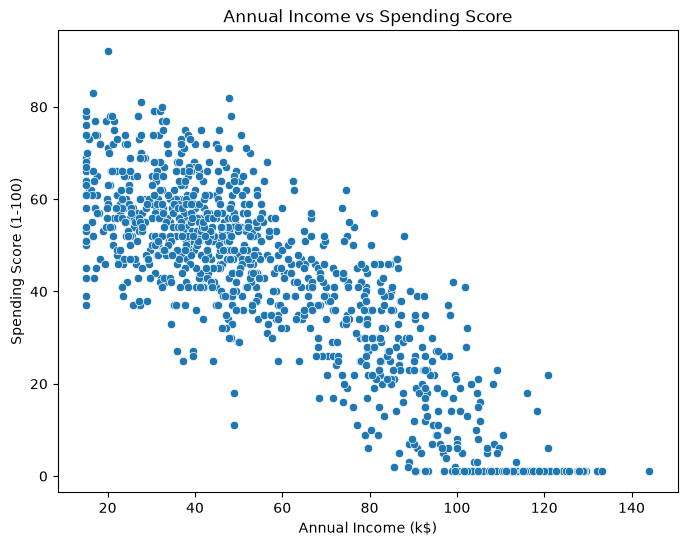

In [3]:

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, 
    x="Annual Income (k$)", 
    y="Spending Score (1-100)"
    )

plt.title("Annual Income vs Spending Score")
plt.show()

### Plot Interpretation

- The scatter plot suggests the presence of multiple dense regions connected by a continuous distribution, indicating that customer groups may exist but are not perfectly separated.
- The high density area appears among lower income customers with relatively high spending scores, while another dense region is observed in higher income customers with relatively low spending scores.
- An overall negative relationship is observed between annual income and spending score, consistent with the correlation analysis performed during exploratory data analysis.
- The exact number of customer segments cannot be determined visually and will be evaluated using K-Means.

## 4. Finding the Optimal Number of Clusters
This section evaluates candidate values of k so the final model is selected using both cluster compactness and separation.

### 4.1 Elbow Method
The elbow method uses within-cluster sum of squares, also called inertia, to assess compactness. Lower inertia indicates tighter clusters, and the elbow point helps identify a reasonable number of clusters before improvements begin to level off.

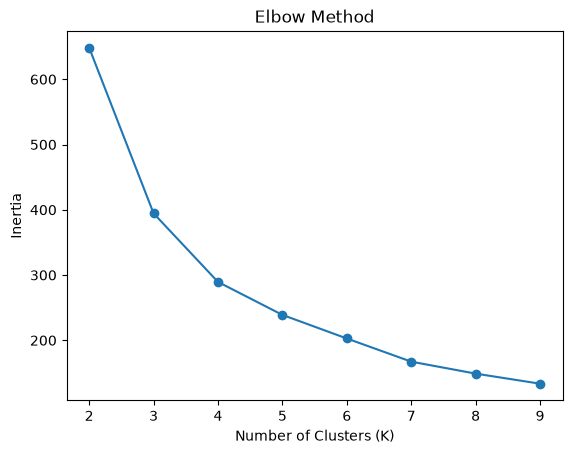

In [4]:
X_scaled, scaler = scale_features(df)

inertia_values = []
k_range = range(2,10)

inertia_results = evaluate_inertia(
    X_scaled,
    k_range
)

plt.plot(
    inertia_results["K"],
    inertia_results["inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

### Elbow Method Interpretation

The inertia decreases significantly as the number of clusters increases from K=2 to K=3, indicating that introducing a third cluster captures important customer structure.

However, the reduction in inertia becomes smaller after K=3, suggesting diminishing returns from adding additional clusters.

Based on the elbow method, K=3 and K=4 are potential candidates. Further evaluation using silhouette score will be performed to determine the most appropriate number of clusters.

### 4.2 Silhouette Score
The silhouette score measures how well separated clusters are. Higher values indicate more clearly defined groups, making it a useful complement to the elbow method when selecting the final number of clusters.

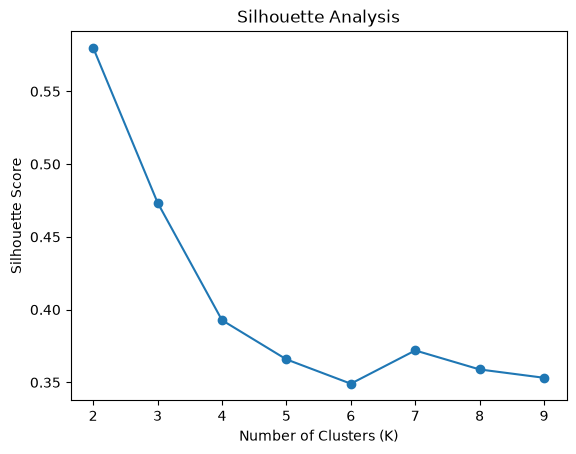

In [5]:
k_values = range(2, 10)
silhouette_results = evaluate_silhouette(
    X_scaled,
    k_range
)

plt.plot(
    silhouette_results["K"],
    silhouette_results["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()

### Silhouette Score Interpretation

From the plot we know that K=2 has the best silhouette score, which means if we use K=2 we can get a more separated data. But considering the business value, K=2 might not provide as much insight as K=3. Additionally K=3 silhouette score is still acceptable. We need more visualisation to do the final decision.

## 5. Comparing Candidate K for K-means clustering

Based on previous section we need to compare which K generate better results between K=2 and K=3.

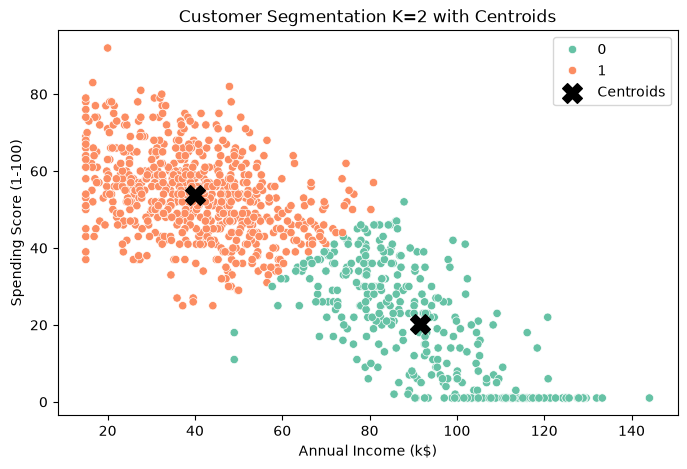

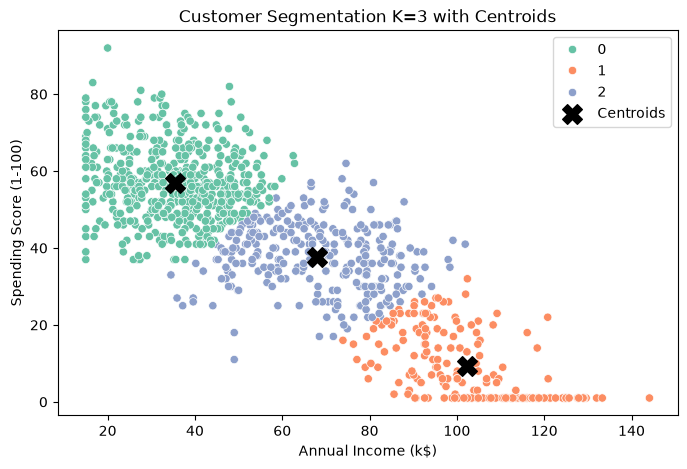

In [6]:
# Training KMeans with 2 clusters
model_k2, labels_k2 = train_kmeans(
    X_scaled,
    n_clusters=2
)

df_k2 = df.copy()
df_k2["Cluster"] = labels_k2

centroids_2 = scaler.inverse_transform(
    model_k2.cluster_centers_
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_k2,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2"
)

plt.scatter(
    centroids_2[:,0],
    centroids_2[:,1],
    marker="X",
    s=200,
    color="black",
    label="Centroids"
)

plt.title("Customer Segmentation K=2 with Centroids")
plt.legend()
plt.show()

# Training KMeans with 3 clusters
model_k3, labels_k3 = train_kmeans(
    X_scaled,
    n_clusters=3
)

df_k3 = df.copy()
df_k3["Cluster"] = labels_k3

centroids_3 = scaler.inverse_transform(
    model_k3.cluster_centers_
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_k3,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2"
)

plt.scatter(
    centroids_3[:,0],
    centroids_3[:,1],
    marker="X",
    s=200,
    color="black",
    label="Centroids"
)

plt.title("Customer Segmentation K=3 with Centroids")
plt.legend()
plt.show()

### Comparing K=2 and K=3 Solutions

The K=2 solution provides stronger cluster separation based on the silhouette score. However, the visualization shows that one cluster contains a relatively wide range of spending behaviors, combining customers with different purchasing patterns.

The K=3 solution creates a more meaningful intermediate customer segment. The additional cluster separates medium-income and medium-spending customers from the two extreme behavioral groups, allowing for more targeted business strategies.

Although K=3 has a slightly lower silhouette score, the resulting clusters provide greater interpretability and business value. Therefore, K=3 is selected as the final clustering solution.

## 6. Final K-Means (K=3) training

We have chosen K=3 as our final number of cluster, and here is the training part.

### 6.1 Checking the proportion of each cluster, making sure it is still healthy

In [7]:
final_kmeans, cluster_labels = train_kmeans(
    X_scaled,
    n_clusters=3
)

df_segmented = df.copy()

df_segmented["Cluster"] = cluster_labels

df_segmented["Cluster"].value_counts()

Cluster
0    527
2    290
1    183
Name: count, dtype: int64

### 6.2 Checking the customer profile for each segmentation

In [8]:
cluster_profile = (
    df_segmented
    .groupby("Cluster")[[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]]
    .mean()
)

cluster_profile

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,35.331879,56.996205
1,102.474863,9.316940
2,68.081724,37.689655


### Analysis for customer proportion and customer profile

- The customer proportion is not balanced but it is still acceptable because each cluster still represents a considerable ammount of customer.
- The customer profile is very good, showing how different each cluster is. This results strengthen our decision to use 3 clusters.

## 7. Visualize Cluster Results
After training the final model, visualize the assigned cluster labels and the cluster centroids.

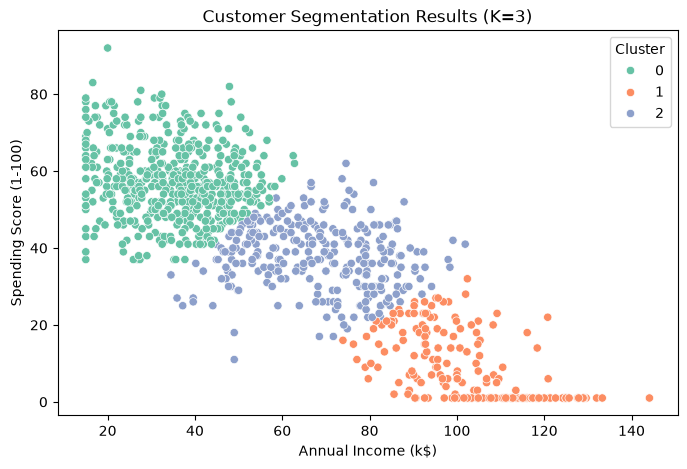

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_segmented,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segmentation Results (K=3)")
plt.show()

## 8. Business Interpretation


### Cluster 0 - Low Income High Engagement Customers

Size = 527 (52.7%)
Income = 35.3k
Spending = 57.0

These customers have lower purchasing power but show relatively strong spending behavior.

Possible characteristics:
- Price-sensitive
- Responsive to promotions
- High engagement despite limited income

### Cluster 2 - Standard Customer

Size = 290 (29.0%)
Income = 68.1k
Spending 37.7

This is the middle segment.

They have:
- Moderate income
- Moderate spending activity

### Cluster 1 - High Income Low Engagement Customers

Size = 183 (18.3%)
Income = 102.5k
Spending = 9.3

This is the high class segment.

These customers have:

- High purchasing ability
- Very low engagement

Potential reasons:

- They do not see enough value from the brand
- They shop elsewhere
- They only purchase occasionally
- Marketing is not effectively reaching them

These segmentation is inline with our hypothesis in EDA

In [10]:
pd.set_option("display.max_colwidth", None)
recommendations = pd.DataFrame({
    "Customer Segment": [
        "Budget High-Engagement Customers",
        "High-Income Low-Engagement Customers",
        "Standard Customers"
    ],
    "Characteristics": [
        "Lower income, relatively high spending",
        "High income but very low spending",
        "Moderate income and moderate spending"
    ],
    "Business Objective": [
        "Retain loyal customers",
        "Re-engage valuable customers",
        "Increase customer value"
    ],
    "Recommended Strategies": [
        "Loyalty programs, discounts, bundle offers",
        "Premium offers, personalized marketing, customer surveys",
        "Personalized recommendations, cross-selling, loyalty upgrades"
    ]
})

recommendations

,Customer Segment,Characteristics,Business Objective,Recommended Strategies
0,Budget High-Engagement Customers,"Lower income, relatively high spending",Retain loyal customers,"Loyalty programs, discounts, bundle offers"
1,High-Income Low-Engagement Customers,High income but very low spending,Re-engage valuable customers,"Premium offers, personalized marketing, customer surveys"
2,Standard Customers,Moderate income and moderate spending,Increase customer value,"Personalized recommendations, cross-selling, loyalty upgrades"


## 9. Conclusion
This project applied K-Means clustering to identify meaningful customer segments based on annual income and spending behavior. Through exploratory data analysis, a strong negative relationship was observed between income and spending score, suggesting the existence of distinct customer purchasing patterns.

Several clustering configurations were evaluated using the Elbow Method and Silhouette Score. Although the two-cluster solution achieved the highest silhouette score, the three-cluster solution was selected because it provided more actionable business insights and better aligned with customer behavior patterns observed during exploration.

The final K-Means model identified three customer segments:

1. Budget High-Engagement Customers

    These customers have relatively lower income but demonstrate strong spending behavior. They represent a large portion of the customer base and are likely to respond well to affordability-focused strategies such as loyalty programs, discounts, and bundle offers.

2. Standard Customers

    These customers have moderate income and spending levels. They represent a balanced customer group where businesses can focus on increasing engagement and customer value through personalized recommendations, cross-selling opportunities, and loyalty upgrades.

3. High-Income Low-Engagement Customers

    These customers have high purchasing power but demonstrate low spending activity. Although they represent a smaller segment, they may provide significant growth opportunities through targeted re-engagement campaigns, premium product recommendations, and personalized marketing.

Overall, the clustering results demonstrate how unsupervised learning techniques can transform raw customer data into actionable business insights. By understanding different customer behaviors, businesses can design more targeted marketing strategies, improve customer retention, and allocate resources more effectively.

Future improvements could include incorporating additional customer attributes, testing alternative clustering algorithms, and validating the segments using real-world business metrics to further improve the reliability and applicability of the segmentation strategy.